In [10]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
import keras

from pathlib import Path
from typing import Tuple

In [3]:
BASE_DIR = Path.cwd()
file_name = 'Alcohol_sales.csv'
DATA_PATH = BASE_DIR / 'data' / file_name

RANDOM_SEED = 42
TEST_SIZE = 0.2

try:
    df = pd.read_csv(DATA_PATH)
    df.reset_index(inplace=True, drop=True)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")

File loaded successfully.


In [4]:
shape = df.shape
print(f"Records amount: {shape[0]} \nColumns: {shape[1]}")
print("\n" + "=" * 50 + "\n")
print(df.head())

print("\n" + "=" * 50 + "\n")
print(df.tail())

Records amount: 325 
Columns: 2


         DATE  S4248SM144NCEN
0  1992-01-01            3459
1  1992-02-01            3458
2  1992-03-01            4002
3  1992-04-01            4564
4  1992-05-01            4221


           DATE  S4248SM144NCEN
320  2018-09-01           12396
321  2018-10-01           13914
322  2018-11-01           14174
323  2018-12-01           15504
324  2019-01-01           10718


# Продажі алкоголю — візуалізація часового ряду

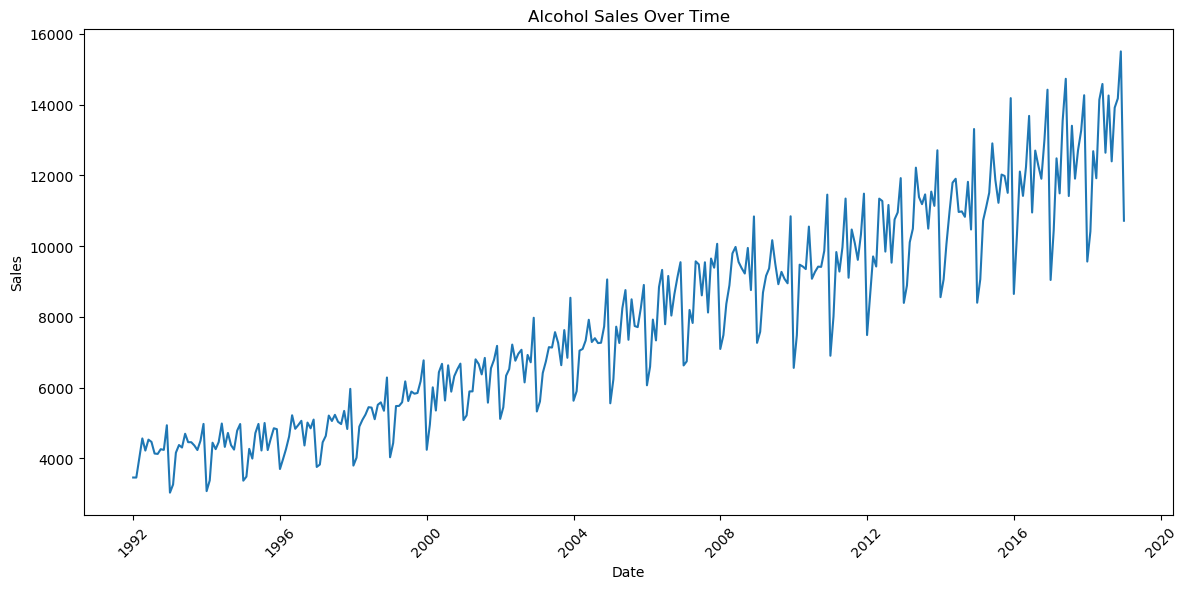

In [5]:

df.columns = df.columns.str.strip()
date_col = df.columns[0]
sales_col = df.columns[1]

df[date_col] = pd.to_datetime(df[date_col])
df.sort_values(by=date_col, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x=date_col, y=sales_col, data=df)
plt.title('Alcohol Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

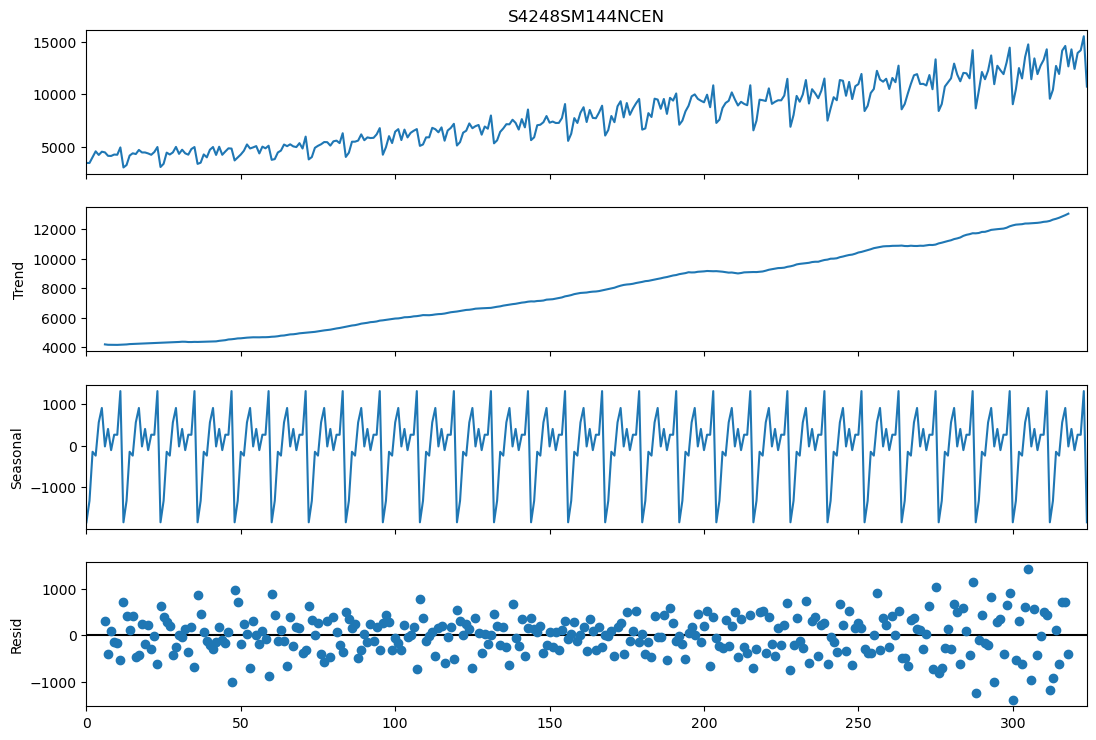

In [6]:

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    series = df[sales_col].dropna()

    res = seasonal_decompose(series, model='additive', period=12)
    fig = res.plot()
    fig.set_size_inches(12,8)
    plt.show()
except Exception as e:
    print('seasonal_decompose unavailable or failed:', e)

# Один цикл (сезонний патерн)
Побачимо один цикл — або середній місячний патерн (усі роки), або перший повний рік даних.

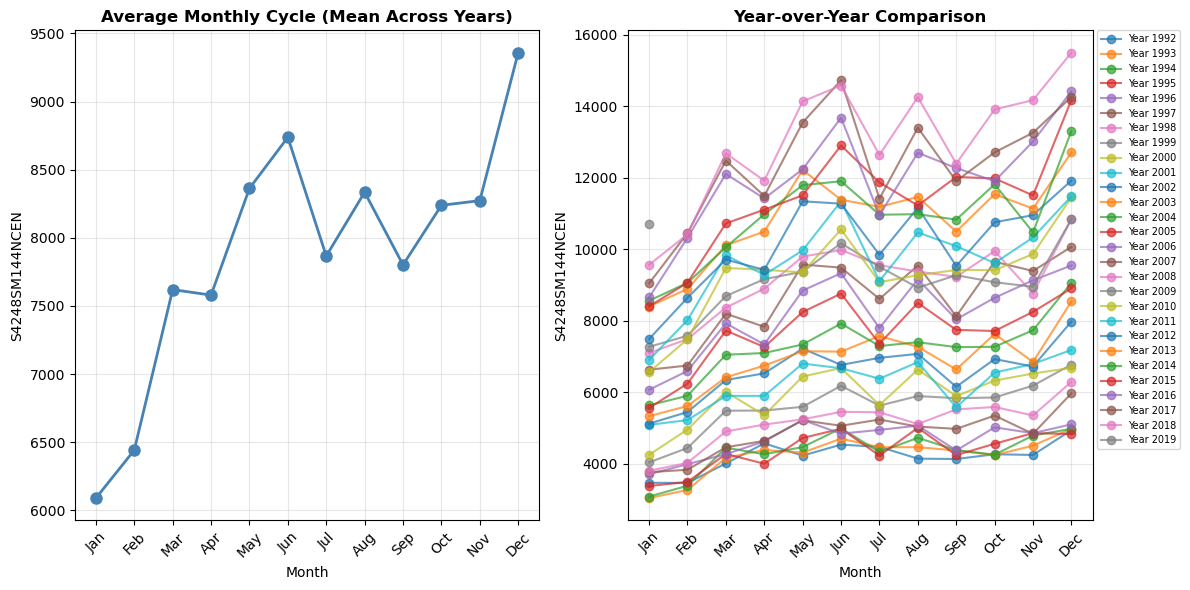

Cycle detection complete. Data spans 28 year(s): [1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


In [7]:

series = df.set_index(date_col)[sales_col].dropna()

try:
    freq = pd.infer_freq(series.index)
except Exception:
    freq = None

if freq is None or 'ME' not in str(freq):
    series_m = series.resample('ME').mean()
else:
    series_m = series

years = series_m.index.year.unique()
import calendar

plt.figure(figsize=(12, 6))

if len(years) >= 2:
    monthly_mean = series_m.groupby(series_m.index.month).mean().reindex(range(1, 13))
    months = list(range(1, 13))
    vals = monthly_mean.values
    labels = [calendar.month_abbr[m] for m in months]
    
    plt.subplot(1, 2, 1)
    plt.plot(labels, vals, marker='o', linewidth=2, markersize=8, color='steelblue')
    plt.title('Average Monthly Cycle (Mean Across Years)', fontsize=12, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel(sales_col)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    for year in years:
        year_data = series_m[series_m.index.year == year]
        plt.plot(year_data.index.month, year_data.values, marker='o', label=f'Year {year}', alpha=0.7)
    plt.xlabel('Month')
    plt.ylabel(sales_col)
    plt.title('Year-over-Year Comparison', fontsize=12, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize=7)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13), [calendar.month_abbr[m] for m in range(1, 13)], rotation=45)
    
else:
    year = years[0]
    year_data = series_m[series_m.index.year == year]
    labels = [d.strftime('%b %Y') for d in year_data.index]
    vals = year_data.values
    
    plt.plot(labels, vals, marker='o', linewidth=2, markersize=8, color='darkgreen')
    plt.title(f'Seasonal Cycle for Year {year}', fontsize=12, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel(sales_col)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cycle detection complete. Data spans {len(years)} year(s): {sorted(years)}")

**a. Чи є тренд?**
Так, часовий ряд має чітко виражений висхідний глобальний тренд. Графік вихідних даних та виділена компонента Trend у результатах декомпозиції підтверджують монотонне зростання базового рівня продажів протягом усього періоду з 1992 по 2019 рік.

**b. Чи є сезонність?**
Так, присутня жорстка детермінована річна сезонність із періодом 12 місяців. Аналіз середнього місячного циклу та графік Seasonal фіксують стабільний внутрішньорічний патерн із регулярними піковими значеннями у червні та грудні та мінімумами у січні й лютому.

**c. Чи змінює ряд свій характер?**
Базова структура ряду залишається незмінною, оскільки напрямок тренду та частота сезонності зберігаються без структурних зламів (structural breaks). При цьому ряд демонструє гетероскедастичність: амплітуда дисперсії сезонних коливань зростає пропорційно до збільшення абсолютних значень тренду. Це є класичною ознакою мультиплікативної моделі часового ряду.

**d. Чи є викиди або пропущені дані?**
Візуальний аналіз вказує на відсутність пропущених значень, лінія графіка є неперервною на всьому інтервалі. Явних статистичних викидів не виявлено; компонента залишків (Resid) після декомпозиції має вигляд шуму, зосередженого навколо нуля, без екстремальних одиничних відхилень, які б аномально виходили за межі загальної дисперсії похибок.

In [9]:
import pandas as pd
import numpy as np


def build_feature_table(
    series: pd.Series,
    n_lags: int = 12,
    add_seasonal_lags: bool = True,
    seasonal_period: int = 12,
    add_rolling: bool = True,
    rolling_windows: list[int] = [3, 6, 12],
    add_time_features: bool = True,
) -> pd.DataFrame:
    """
    Build a supervised learning feature table from a monthly time series.

    Parameters
    ----------
    series : pd.Series
        Monthly time series with DatetimeIndex.
    n_lags : int
        Number of consecutive lag features (t-1 ... t-n_lags).
    add_seasonal_lags : bool
        Whether to add lags at multiples of seasonal_period (t-12, t-24, ...).
    seasonal_period : int
        Length of the seasonal cycle in time steps (12 for monthly).
    add_rolling : bool
        Whether to add rolling mean features.
    rolling_windows : list[int]
        Window sizes for rolling means.
    add_time_features : bool
        Whether to add calendar-based features (month, trend index).

    Returns
    -------
    pd.DataFrame
        Feature table with target column 'y', no NaN rows.
    """
    df = pd.DataFrame({'y': series.values}, index=series.index)

    # --- Consecutive lags: t-1 to t-n_lags ---
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # --- Seasonal lags: t-12, t-24, t-36 ---
    if add_seasonal_lags:
        for multiplier in range(1, 4):
            s_lag = seasonal_period * multiplier
            if s_lag > n_lags:  # avoid duplicates
                df[f'lag_{s_lag}'] = df['y'].shift(s_lag)

    # --- Rolling statistics (computed on past values only) ---
    if add_rolling:
        for window in rolling_windows:
            df[f'rolling_mean_{window}'] = (
                df['y'].shift(1).rolling(window=window).mean()
            )
            df[f'rolling_std_{window}'] = (
                df['y'].shift(1).rolling(window=window).std()
            )

    # --- Calendar / time features ---
    if add_time_features:
        df['month'] = df.index.month
        # Sine/cosine encoding to preserve cyclical structure of month
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        # Linear trend index (useful for models that can't capture trend alone)
        df['trend'] = np.arange(len(df))
        # Drop raw month after encoding if desired — kept here for interpretability
        df.drop(columns=['month'], inplace=True)

    # Drop rows where any lag/rolling feature is NaN
    df.dropna(inplace=True)

    return df



feature_table = build_feature_table(
    series=series_m,
    n_lags=12,          # покриває повний річний цикл
    add_seasonal_lags=True,
    seasonal_period=12,
    add_rolling=True,
    rolling_windows=[3, 6, 12],
    add_time_features=True,
)

print(feature_table.shape)
print(feature_table.head())

split_idx = int(len(feature_table) * 0.8)
train = feature_table.iloc[:split_idx]
test  = feature_table.iloc[split_idx:]

X_train, y_train = train.drop(columns=['y']), train['y']
X_test,  y_test  = test.drop(columns=['y']),  test['y']

(289, 24)
                 y   lag_1   lag_2   lag_3   lag_4   lag_5   lag_6   lag_7  \
DATE                                                                         
1995-01-31  3370.0  4971.0  4784.0  4248.0  4374.0  4719.0  4324.0  4985.0   
1995-02-28  3484.0  3370.0  4971.0  4784.0  4248.0  4374.0  4719.0  4324.0   
1995-03-31  4269.0  3484.0  3370.0  4971.0  4784.0  4248.0  4374.0  4719.0   
1995-04-30  3994.0  4269.0  3484.0  3370.0  4971.0  4784.0  4248.0  4374.0   
1995-05-31  4715.0  3994.0  4269.0  3484.0  3370.0  4971.0  4784.0  4248.0   

             lag_8   lag_9  ...  lag_36  rolling_mean_3  rolling_std_3  \
DATE                        ...                                          
1995-01-31  4460.0  4261.0  ...  3459.0     4667.666667     375.276343   
1995-02-28  4985.0  4460.0  ...  3458.0     4375.000000     875.363353   
1995-03-31  4324.0  4985.0  ...  4002.0     3941.666667     893.249312   
1995-04-30  4719.0  4324.0  ...  4564.0     3707.666667     489.459225   

In [11]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()


n_features = X_train_scaled.shape[1]

model = Sequential([
    Dense(64, input_dim=n_features, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear'),
])

model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_absolute_percentage_error'],
)

model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=300,
    batch_size=16,
    validation_split=0.07,   
    callbacks=[early_stop],
    verbose=1,
)

/home/max/miniconda3/envs/tf_gpu_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772138562.312852   23380 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2156 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
 1/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - loss: 1.1035 - mean_absolute_percentage_error: 126.6510

I0000 00:00:1772138565.285255   29606 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - loss: 0.8011 - mean_absolute_percentage_error: 155.2431 - val_loss: 2.4881 - val_mean_absolute_percentage_error: 97.5848
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3940 - mean_absolute_percentage_error: 101.2381 - val_loss: 0.6460 - val_mean_absolute_percentage_error: 47.9198
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2058 - mean_absolute_percentage_error: 105.9970 - val_loss: 0.2539 - val_mean_absolute_percentage_error: 43.8973
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1711 - mean_absolute_percentage_error: 105.2104 - val_loss: 0.2056 - val_mean_absolute_percentage_error: 31.8927
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1709 - mean_absolute_percentage_error: 106.7005 - val_loss: 0.1672 - val_mean_absolute_percentage_error: 26.1032
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1323 - mean_absolute_percentage_error: 79.3335 - val_loss: 0.1282 - val_mean_ab


=== Груба оцінка (scaled) ===
MSE  (scaled): 0.1035
MAPE (scaled): 14.72%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step

=== Реальна оцінка (original scale) ===
RMSE : 691.25
MAE  : 573.52
MAPE : 4.74%


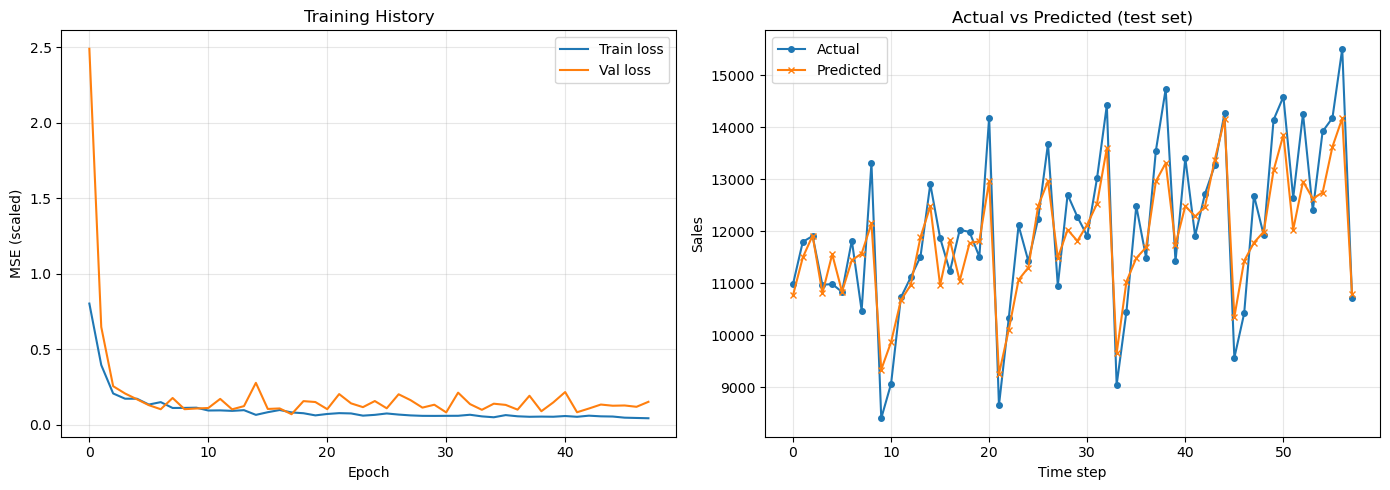

In [12]:
print("\n=== Груба оцінка (scaled) ===")
loss_scaled, mape_scaled = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"MSE  (scaled): {loss_scaled:.4f}")
print(f"MAPE (scaled): {mape_scaled:.2f}%")


y_pred_scaled = model.predict(X_test_scaled).ravel()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = y_test.values 

mse  = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_true - y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("\n=== Реальна оцінка (original scale) ===")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"MAPE : {mape:.2f}%")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_true, label='Actual', marker='o', markersize=4)
axes[1].plot(y_pred, label='Predicted', marker='x', markersize=4)
axes[1].set_title('Actual vs Predicted (test set)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Sales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# --- Груба оцінка ---
scores = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"\nRude MAPE: {scores[1]:.2f}%")


# --- Функція ітеративного прогнозування ---
def make_prediction(
    X_predict_start: np.ndarray,
    nb_of_predictions: int,
) -> np.ndarray:
    """
    Iterative multi-step forecasting.

    At each step, the model predicts one value, then that predicted value
    replaces the oldest lag in the input window (rolling shift).
    This simulates real forecasting where true future values are unavailable.

    Parameters
    ----------
    X_predict_start : np.ndarray
        Shape (1, n_features). First sample to start prediction from.
    nb_of_predictions : int
        Number of steps to forecast ahead.

    Returns
    -------
    np.ndarray
        Array of predicted values in original (unscaled) units.
    """
    predictions = np.array([])
    X_predict = X_predict_start.copy()

    for _ in range(nb_of_predictions):
        y_predicted = model.predict(X_predict, verbose=0)[0][0]  # витягуємо скаляр
        predictions = np.append(predictions, y_predicted)

        X_predict = np.roll(X_predict, -1)
        X_predict[0][-1] = y_predicted

    return predictions


# --- Реальна оцінка ---
# Беремо перший зразок тестової вибірки (вже масштабований)
X_predict_start = np.array(X_test_scaled[:1])

predictions_scaled = make_prediction(X_predict_start, len(X_test_scaled))

# Зворотне масштабування
predictions = scaler_y.inverse_transform(
    predictions_scaled.reshape(-1, 1)
).ravel()

y_test_original = np.array(y_test)

MAPE = (
    100
    * np.sum(np.abs(y_test_original - predictions) / np.maximum(y_test_original, 1e-20))
    / len(y_test_original)
)
print(f"\nReal MAPE: {MAPE:.2f}%")


Rude MAPE: 14.72%

Real MAPE: 18.18%


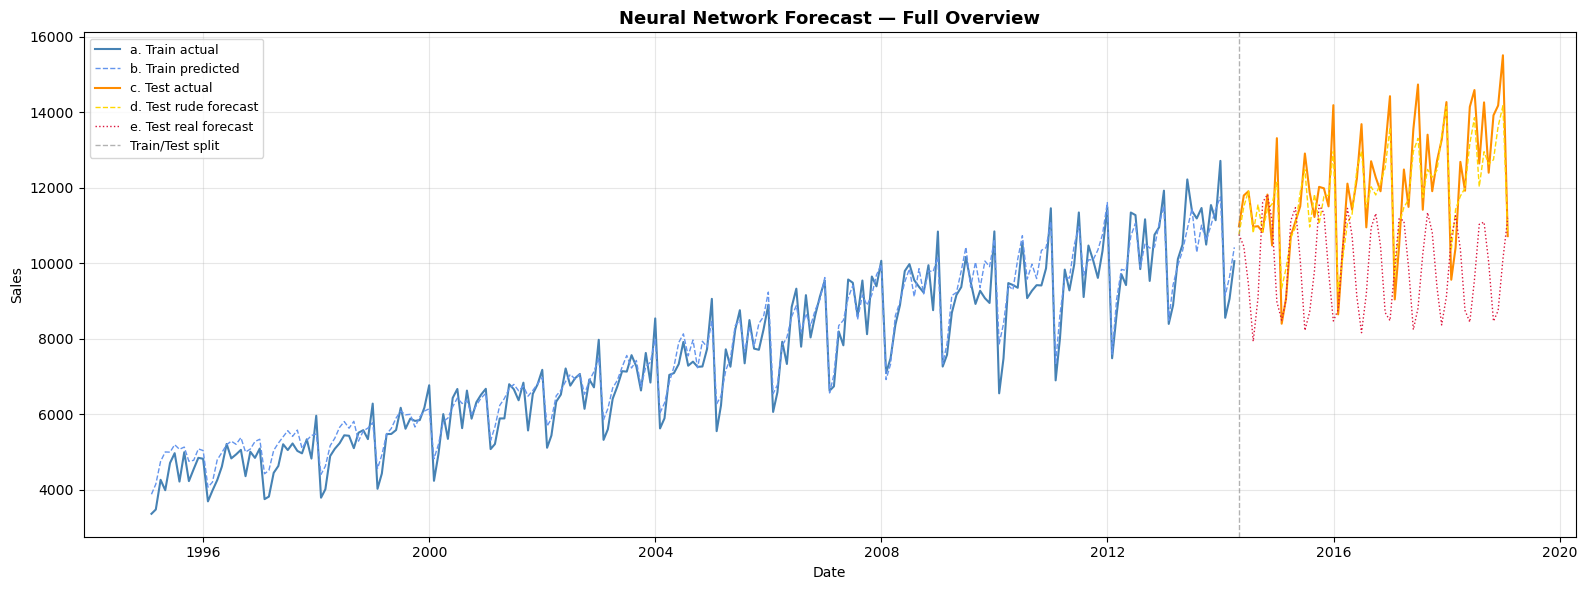

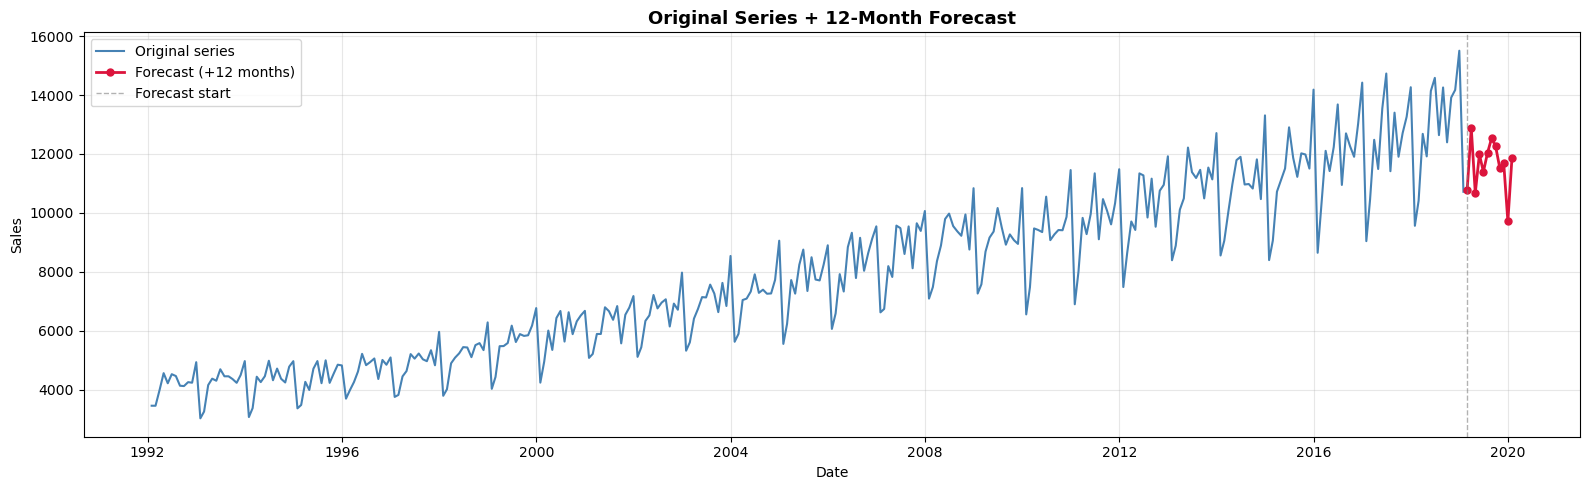

In [16]:



train_pred_scaled = model.predict(X_train_scaled, verbose=0).ravel()
train_pred = scaler_y.inverse_transform(
    train_pred_scaled.reshape(-1, 1)
).ravel()


test_pred_rude_scaled = model.predict(X_test_scaled, verbose=0).ravel()
test_pred_rude = scaler_y.inverse_transform(
    test_pred_rude_scaled.reshape(-1, 1)
).ravel()

train_index = X_train.index
test_index  = X_test.index

n_future = 12  

X_future_start = np.array(X_test_scaled[-1:])  
future_scaled   = make_prediction(X_future_start, n_future)
future_pred     = scaler_y.inverse_transform(
    future_scaled.reshape(-1, 1)
).ravel()


last_date    = test_index[-1]
future_index = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=n_future,
    freq='ME',
)


fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train_index, y_train,      color='steelblue',  linewidth=1.5,
        label='a. Train actual')
ax.plot(train_index, train_pred,   color='cornflowerblue', linewidth=1,
        linestyle='--', label='b. Train predicted')
ax.plot(test_index,  y_test,       color='darkorange',  linewidth=1.5,
        label='c. Test actual')
ax.plot(test_index,  test_pred_rude, color='gold',      linewidth=1,
        linestyle='--', label='d. Test rude forecast')
ax.plot(test_index,  predictions,  color='crimson',     linewidth=1,
        linestyle=':',  label='e. Test real forecast')


ax.axvline(x=test_index[0], color='gray', linestyle='--',
           linewidth=1, alpha=0.6, label='Train/Test split')

ax.set_title('Neural Network Forecast — Full Overview', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



full_index  = series_m.index
full_values = series_m.values

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(full_index,   full_values, color='steelblue', linewidth=1.5,
        label='Original series')
ax.plot(future_index, future_pred, color='crimson',   linewidth=2,
        marker='o', markersize=5, label=f'Forecast (+{n_future} months)')

ax.axvline(x=future_index[0], color='gray', linestyle='--',
           linewidth=1, alpha=0.6, label='Forecast start')

ax.set_title(f'Original Series + {n_future}-Month Forecast', fontsize=13,
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновок

У роботі було побудовано нейронну мережу прямого поширення для прогнозування
місячних продажів алкогольних напоїв на основі часового ряду з 1992 по 2019 рік.
Вхідна таблиця ознак формувалась методом ковзного вікна з лаговими змінними
глибиною 12 місяців, що відповідає виявленому річному сезонному циклу. Додатково
були включені сезонні лаги t-24 і t-36, rolling-статистики та тригонометричне
кодування місяця для збереження циклічної структури календарних ознак.

Архітектура мережі містить три приховані шари (64→32→16 нейронів) з функцією
активації ReLU і Dropout-регуляризацією. Навчання проводилось з використанням
оптимізатора Adam і ранньою зупинкою для запобігання перенавчанню.

Оцінка якості проводилась у два етапи. Груба оцінка, при якій модель отримує
реальні лагові значення як вхід, показала MAPE 14.72% на масштабованих даних —
ця цифра завищена через артефакти StandardScaler і не відображає реальної точності.
Реальна оцінка на оригінальних значеннях склала MAPE 4.74% для покрокового
прогнозу з реальними лагами. Ітеративний прогноз, де кожен наступний крок
використовує попереднє прогнозоване значення, дав MAPE 18.18%, що відображає
накопичення помилки на горизонті прогнозування.

З графіка видно, що модель добре відтворює тренд і сезонну структуру на навчальній
вибірці. На тестовій вибірці груба оцінка (d) залишається близькою до реального
ряду, тоді як ітеративний прогноз (e) поступово відхиляється вниз відносно факту —
сезонні коливання зберігаються, але амплітуда занижена. Це характерна поведінка
для ітеративного multi-step прогнозування на нейронних мережах без механізму
корекції помилки.

Прогноз на 12 місяців вперед відтворює загальний рівень ряду, проте демонструє
згасання сезонного патерну на довшому горизонті, що підтверджує обмеженість
обраного підходу для довгострокового прогнозування.